# A production API for your model — the hands-on half

The practical companion to **`api_slides.html`**. By the end, a real HTTP server is running on
your machine: it rejects bad input with a useful error and answers predictions in milliseconds.

### What is an API, in one paragraph

An **API** is two programs agreeing on how to talk. Yours listens at an address; anything that can
send an **HTTP request** — a website, a phone app, Excel, another team's service — sends JSON and
gets a prediction back. A request carries a **method** (`GET` to read, `POST` to send), a **path**
(`/predict`) and usually a JSON **body**; the reply carries a **status code** (`200` fine, `422`
your input was wrong, `500` our bug) and a body.

This session builds a **REST** API — one request in, one prediction out, nothing remembered
between calls.

| Part | Deck slides | What you do |
|---|---|---|
| 0 · Setup | 18 | install, sandbox, train a model worth serving |
| 1 · Pydantic | 21–22 | describe the request, watch it reject nonsense |
| 2 · The app | 23–27 | `lifespan` model loading, `/health`, `/predict` |
| 3 · Tests | 28 | `TestClient` — full API tests with no server |
| 4 · A real server | 29–30 | launch uvicorn, hit it over HTTP, measure latency, see `/docs` |
| 5 · Advanced | 31–37 | batch, errors, API keys, middleware, versioning |

**The problem this solves:** a model in a notebook is useful to exactly one person. An API
turns it into something a website, a job, or another team can call.

Everything runs in a throwaway `api_demo/` folder; the last cell stops the server and deletes it.

## Step 0.1 · Install

In [1]:
!pip install -q fastapi 'pydantic>=2' uvicorn scikit-learn pandas requests httpx

Four packages: FastAPI builds the API, Pydantic validates what arrives, uvicorn runs the server,
and scikit-learn supplies the model to serve.

In [2]:
import fastapi, pydantic, uvicorn, sklearn
print("fastapi ", fastapi.__version__)
print("pydantic", pydantic.VERSION)
print("uvicorn ", uvicorn.__version__)
print("sklearn ", sklearn.__version__)

fastapi  0.115.2
pydantic 2.11.10
uvicorn  0.31.1
sklearn  1.6.1


/home/shamaseen/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/shamaseen/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Step 0.2 · A sandbox to work in

In [3]:
import os, shutil, pathlib

BASE = pathlib.Path.cwd()          # the folder this notebook lives in
PROJ = BASE / "api_demo"           # a throwaway sandbox, deleted by the last cell

if PROJ.exists():
    shutil.rmtree(PROJ)            # re-running this notebook is always safe
PROJ.mkdir(parents=True)
os.chdir(PROJ)
print("working inside:", os.getcwd())

working inside: /home/shamaseen/Desktop/Shai/qafza/free_Training/qafza-free-traning/03-production-api/api_demo


## Step 0.3 · Train something worth serving

A small churn pipeline — the same shape as session 1, and for the same reason: we persist the
**whole pipeline**, so the API never needs its own copy of the preprocessing code.

In [4]:
import numpy as np, pandas as pd, joblib, os
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

rng = np.random.default_rng(0)
m = 4000
df = pd.DataFrame({
    "tenure_months":  rng.integers(1, 72, m),
    "monthly_charge": rng.normal(65, 20, m).round(2),
    "support_calls":  rng.poisson(1.2, m),
    "plan":           rng.choice(["basic", "plus", "pro"], m, p=[.5, .3, .2]),
})
sc = (-0.04*df.tenure_months + 0.03*df.monthly_charge + 0.55*df.support_calls
      + rng.normal(0, .8, m))
df["churn"] = (sc > sc.mean()).astype(int)


Now the model. It is session 1's leak-proof `Pipeline`, unchanged — the point here is what
gets **saved**: the pipeline, the column order and a version string, together in one file.


In [5]:
NUM, CAT = ["tenure_months", "monthly_charge", "support_calls"], ["plan"]
pipe = Pipeline([
    ("pre", ColumnTransformer([
        ("num", Pipeline([("i", SimpleImputer(strategy="median")), ("s", StandardScaler())]), NUM),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CAT)])),
    ("model", RandomForestClassifier(n_estimators=150, random_state=0))])

Xtr, Xte, ytr, yte = train_test_split(df[NUM+CAT], df.churn, test_size=.25,
                                      random_state=0, stratify=df.churn)
pipe.fit(Xtr, ytr)
auc = roc_auc_score(yte, pipe.predict_proba(Xte)[:, 1])

os.makedirs("app", exist_ok=True)
joblib.dump({"pipeline": pipe, "version": "1.0.0", "features": NUM + CAT,
             "trained_rows": len(Xtr), "test_roc_auc": round(float(auc), 4)},
            "app/model.joblib")
print(f"test ROC AUC {auc:.4f}  ->  saved app/model.joblib")

test ROC AUC 0.8653  ->  saved app/model.joblib


---
# Part 1 — Pydantic: the front door   ·   deck slides 21–22

An API is a **trust boundary**. Everything arriving from outside is a stranger's guess about
what you wanted: strings where you expect numbers, missing fields, `null`, a plan called
`"PRO "` with a trailing space, `tenure_months: -5`.

Pydantic lets you *declare* the shape you accept. FastAPI then rejects anything else before
your code runs, with an error message that tells the caller exactly what was wrong.

In [6]:
%%writefile app/schemas.py
"""Request and response shapes. This file IS the API contract.

typing.Optional / typing.List rather than `str | None` and `list[...]`: PEP 604 unions
need Python 3.10, and an API that only imports on the newest interpreter is a support
problem you do not need.
"""
from typing import List, Literal, Optional

from pydantic import BaseModel, Field, ConfigDict


class Customer(BaseModel):
    """One customer to score. Field(...) carries the validation rules."""
    model_config = ConfigDict(
        extra="forbid",                 # a typo'd field is an error, not a shrug
        json_schema_extra={"examples": [
            {"tenure_months": 12, "monthly_charge": 79.99,
             "support_calls": 3, "plan": "pro"}]})

    tenure_months:  int   = Field(ge=0, le=600,    description="months since signup")
    monthly_charge: float = Field(ge=0, le=10_000, description="current monthly bill")
    support_calls:  int   = Field(ge=0, le=100,    description="calls in the last 90 days")
    plan: Literal["basic", "plus", "pro"]           # anything else is rejected


class Prediction(BaseModel):
    """What we promise to return. Declaring it stops accidental contract changes."""
    churn: bool
    probability: float = Field(ge=0, le=1)
    model_version: str
    request_id: str


class BatchRequest(BaseModel):
    customers: List[Customer] = Field(min_length=1, max_length=1000)


class Health(BaseModel):
    status: Literal["ok", "degraded"]
    model_loaded: bool
    model_version: Optional[str] = None


Writing app/schemas.py


Validation is not theory — try it directly, with no web server involved.

In [7]:
import sys; sys.path.insert(0, ".")
from app.schemas import Customer
from pydantic import ValidationError

good = Customer(tenure_months=12, monthly_charge=79.99, support_calls=3, plan="pro")
print("accepted:", good.model_dump())

for bad, why in [
    ({"tenure_months": -5, "monthly_charge": 50, "support_calls": 1, "plan": "pro"}, "negative tenure"),
    ({"tenure_months": 12, "monthly_charge": 50, "support_calls": 1, "plan": "gold"}, "no such plan"),
    ({"tenure_months": 12, "monthly_charge": 50, "plan": "pro"},                      "missing field"),
    ({"tenure_months": 12, "monthly_charge": 50, "support_calls": 1, "plan": "pro",
      "tenure": 4},                                                                  "unexpected field"),
]:
    try:
        Customer(**bad); print(f"  {why:20} -> ACCEPTED (should not happen)")
    except ValidationError as e:
        err = e.errors()[0]
        print(f"  {why:20} -> rejected: {err['loc']} {err['msg'][:52]}")

accepted: {'tenure_months': 12, 'monthly_charge': 79.99, 'support_calls': 3, 'plan': 'pro'}
  negative tenure      -> rejected: ('tenure_months',) Input should be greater than or equal to 0
  no such plan         -> rejected: ('plan',) Input should be 'basic', 'plus' or 'pro'
  missing field        -> rejected: ('support_calls',) Field required
  unexpected field     -> rejected: ('tenure',) Extra inputs are not permitted


> **Why `extra="forbid"` matters.** Without it, a caller who sends `tenure` instead of
> `tenure_months` gets a *silent default* and a confidently wrong prediction. With it they get
> an error that names the field. Silent acceptance of unknown fields is how bad data gets into
> production one typo at a time.

---
# Part 2 — The application   ·   deck slides 23–27

## Step 2.0 · The smallest API that works

Before the production version, here is the whole idea in twelve lines. Load the model, declare one
endpoint, return a number.


In [8]:
%%writefile app/tiny.py
"""The smallest useful model API. Everything after this is about surviving production."""
import joblib
import pandas as pd
from fastapi import FastAPI

from app.schemas import Customer

model = joblib.load("app/model.joblib")     # loaded once, when the server starts
app = FastAPI()


@app.post("/predict")
def predict(customer: Customer):
    row = pd.DataFrame([customer.model_dump()])[model["features"]]
    probability = model["pipeline"].predict_proba(row)[0, 1]
    return {"churn": bool(probability >= 0.5), "probability": round(float(probability), 4)}


Writing app/tiny.py


That is a working API. Try it without a server, the same way you tried the schema:

In [9]:
from fastapi.testclient import TestClient
import importlib, app.tiny

importlib.reload(app.tiny)
with TestClient(app.tiny.app) as client:
    r = client.post("/predict", json={"tenure_months": 2, "monthly_charge": 130.0,
                                      "support_calls": 8, "plan": "basic"})
    print("POST /predict ->", r.status_code, r.json())

    bad = client.post("/predict", json={"tenure_months": -1, "plan": "gold"})
    print("bad input     ->", bad.status_code, "(rejected before the model ran)")


POST /predict -> 200 {'churn': True, 'probability': 0.9867}
bad input     -> 422 (rejected before the model ran)


### Now the production version

Twelve lines is enough to demonstrate the idea and not enough to run a service. The rest of this
part adds the four things a real one needs:

| Missing | Added below |
|---|---|
| the load balancer cannot tell if it is alive | `GET /health` |
| a crash leaks a stack trace to the caller | one exception handler |
| scoring 100 customers means 100 requests | `POST /predict/batch` |
| nobody knows which model answered | a version in every response |


In [10]:
%%writefile app/main.py
"""A model API small enough to read in one sitting, shaped like a real one."""
import logging, os, time, uuid
from contextlib import asynccontextmanager

import joblib
import pandas as pd
from fastapi import FastAPI, HTTPException, Request
from fastapi.responses import JSONResponse

from typing import List, Tuple

from app.schemas import BatchRequest, Customer, Health, Prediction

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")
log = logging.getLogger("api")

ARTIFACT = os.getenv("MODEL_PATH", "app/model.joblib")
STATE: dict = {}


@asynccontextmanager
async def lifespan(app: FastAPI):
    # startup: load the model ONCE. Loading per request would add ~50ms to every call.
    STATE["bundle"] = joblib.load(ARTIFACT)
    log.info("model %s loaded from %s", STATE["bundle"]["version"], ARTIFACT)
    yield
    STATE.clear()                      # shutdown: let go of it cleanly
    log.info("model unloaded")


app = FastAPI(
    title="Churn API",
    version="1.0.0",
    summary="Scores a customer's probability of churning.",
    lifespan=lifespan,
)


@app.middleware("http")
async def add_timing(request: Request, call_next):
    """Every response carries how long it took. Cheap, and priceless when it gets slow."""
    t0 = time.perf_counter()
    response = await call_next(request)
    response.headers["X-Process-Time-ms"] = f"{(time.perf_counter() - t0) * 1000:.2f}"
    return response


Writing app/main.py


### Now the endpoints

`%%writefile -a` **appends** to the same file, so the app is written in two readable halves
rather than one wall. Above was the setup: load the model once, time every request. Below is
the part that answers.


In [11]:
%%writefile -a app/main.py
@app.get("/health", response_model=Health, tags=["ops"])
def health():
    """Liveness. Returns degraded rather than 500 so an orchestrator can tell them apart."""
    b = STATE.get("bundle")
    return Health(status="ok" if b else "degraded",
                  model_loaded=b is not None,
                  model_version=b["version"] if b else None)


def _score(rows: List[Customer]) -> List[Tuple[bool, float]]:
    b = STATE.get("bundle")
    if b is None:                                    # never guess when the model is missing
        raise HTTPException(status_code=503, detail="model not loaded")
    frame = pd.DataFrame([r.model_dump() for r in rows])[b["features"]]
    proba = b["pipeline"].predict_proba(frame)[:, 1]
    return [(bool(p >= 0.5), float(round(p, 4))) for p in proba]


@app.post("/predict", response_model=Prediction, tags=["model"])
def predict(customer: Customer):
    churn, proba = _score([customer])[0]
    return Prediction(churn=churn, probability=proba,
                      model_version=STATE["bundle"]["version"],
                      request_id=str(uuid.uuid4())[:8])


@app.post("/predict/batch", response_model=List[Prediction], tags=["model"])
def predict_batch(body: BatchRequest):
    """One model call for the whole batch -- far cheaper than N separate requests."""
    out = _score(body.customers)
    v = STATE["bundle"]["version"]
    return [Prediction(churn=c, probability=p, model_version=v,
                       request_id=str(uuid.uuid4())[:8]) for c, p in out]


@app.exception_handler(Exception)
async def unhandled(request: Request, exc: Exception):
    """Log the detail, return something generic. Stack traces are not for callers."""
    log.exception("unhandled error on %s", request.url.path)
    return JSONResponse(status_code=500, content={"detail": "internal error"})

Appending to app/main.py


The whole service, listed. Ninety lines — worth reading once end to end before running it.

In [12]:
!ls -la app/
print("\n--- the app is ~90 lines, and that is the whole service ---")

total 13220
drwxrwxr-x 3 shamaseen shamaseen     4096 Sep  6 16:55 .
drwxrwxr-x 3 shamaseen shamaseen     4096 Sep  6 16:55 ..
-rw-rw-r-- 1 shamaseen shamaseen     3285 Sep  6 16:55 main.py
-rw-rw-r-- 1 shamaseen shamaseen 13512511 Sep  6 16:55 model.joblib
drwxrwxr-x 2 shamaseen shamaseen     4096 Sep  6 16:55 __pycache__
-rw-rw-r-- 1 shamaseen shamaseen     1521 Sep  6 16:55 schemas.py
-rw-rw-r-- 1 shamaseen shamaseen      562 Sep  6 16:55 tiny.py

--- the app is ~90 lines, and that is the whole service ---


---
# Part 3 — Test it without a server   ·   deck slide 28

`TestClient` runs the whole application in-process: real routing, real validation, real
responses, no port, no waiting. Fast enough to run on every commit.

In [13]:
from fastapi.testclient import TestClient
from app.main import app

client = TestClient(app)          # entering the context runs the lifespan startup

with client:
    h = client.get("/health")
    print("GET /health ", h.status_code, h.json())

    ok = client.post("/predict", json={"tenure_months": 3, "monthly_charge": 95.0,
                                       "support_calls": 6, "plan": "basic"})
    print("POST /predict", ok.status_code, ok.json())

    bad = client.post("/predict", json={"tenure_months": -1, "monthly_charge": 95.0,
                                        "support_calls": 6, "plan": "gold"})
    print("POST /predict (bad)", bad.status_code)
    for e in bad.json()["detail"]:
        print("   ", e["loc"], "->", e["msg"][:58])

2026-09-06 16:55:23,825 INFO model 1.0.0 loaded from app/model.joblib
2026-09-06 16:55:23,827 INFO HTTP Request: GET http://testserver/health "HTTP/1.1 200 OK"
2026-09-06 16:55:23,837 INFO HTTP Request: POST http://testserver/predict "HTTP/1.1 200 OK"
2026-09-06 16:55:23,839 INFO HTTP Request: POST http://testserver/predict "HTTP/1.1 422 Unprocessable Entity"
2026-09-06 16:55:23,840 INFO model unloaded


GET /health  200 {'status': 'ok', 'model_loaded': True, 'model_version': '1.0.0'}
POST /predict 200 {'churn': True, 'probability': 1.0, 'model_version': '1.0.0', 'request_id': '3de99770'}
POST /predict (bad) 422
    ['body', 'tenure_months'] -> Input should be greater than or equal to 0
    ['body', 'plan'] -> Input should be 'basic', 'plus' or 'pro'


Two things to notice in that output:

* the bad request came back **422**, not 500 — the caller's mistake is reported as the caller's
  mistake, with the offending field named;
* you never wrote that error message. It came from the schema.

In [14]:
# a small test suite -- this is what runs in CI
def test_health_ok():
    with TestClient(app) as c:
        assert c.get("/health").json()["model_loaded"] is True

def test_predict_shape():
    with TestClient(app) as c:
        r = c.post("/predict", json={"tenure_months": 12, "monthly_charge": 60.0,
                                     "support_calls": 1, "plan": "pro"}).json()
        assert set(r) == {"churn", "probability", "model_version", "request_id"}
        assert 0.0 <= r["probability"] <= 1.0

def test_rejects_unknown_plan():
    with TestClient(app) as c:
        assert c.post("/predict", json={"tenure_months": 12, "monthly_charge": 60.0,
                                        "support_calls": 1, "plan": "platinum"}).status_code == 422

def test_batch_returns_one_per_customer():
    with TestClient(app) as c:
        body = {"customers": [{"tenure_months": i, "monthly_charge": 50.0,
                               "support_calls": 0, "plan": "basic"} for i in range(5)]}
        assert len(c.post("/predict/batch", json=body).json()) == 5

for t in [test_health_ok, test_predict_shape, test_rejects_unknown_plan,
          test_batch_returns_one_per_customer]:
    t(); print("PASS", t.__name__)

2026-09-06 16:55:23,868 INFO model 1.0.0 loaded from app/model.joblib
2026-09-06 16:55:23,870 INFO HTTP Request: GET http://testserver/health "HTTP/1.1 200 OK"
2026-09-06 16:55:23,871 INFO model unloaded


PASS test_health_ok


2026-09-06 16:55:23,895 INFO model 1.0.0 loaded from app/model.joblib
2026-09-06 16:55:23,905 INFO HTTP Request: POST http://testserver/predict "HTTP/1.1 200 OK"
2026-09-06 16:55:23,906 INFO model unloaded
2026-09-06 16:55:23,930 INFO model 1.0.0 loaded from app/model.joblib
2026-09-06 16:55:23,932 INFO HTTP Request: POST http://testserver/predict "HTTP/1.1 422 Unprocessable Entity"
2026-09-06 16:55:23,933 INFO model unloaded
2026-09-06 16:55:23,955 INFO model 1.0.0 loaded from app/model.joblib
2026-09-06 16:55:23,965 INFO HTTP Request: POST http://testserver/predict/batch "HTTP/1.1 200 OK"
2026-09-06 16:55:23,966 INFO model unloaded


PASS test_predict_shape
PASS test_rejects_unknown_plan
PASS test_batch_returns_one_per_customer


---
# Part 4 — A real server over real HTTP   ·   deck slides 29–30

`TestClient` proves the logic. It does not prove that uvicorn serves it, that the port binds,
or how fast it is. So now start the actual server.

In [15]:
import subprocess, socket, sys, time, urllib.request

def free_port(start=8000):
    for p in range(start, start + 50):
        with socket.socket() as s:
            if s.connect_ex(("127.0.0.1", p)) != 0:
                return p
    raise RuntimeError("no free port")

PORT = free_port()
URL = f"http://127.0.0.1:{PORT}"

SERVER = subprocess.Popen(
    [sys.executable, "-m", "uvicorn", "app.main:app", "--host", "127.0.0.1",
     "--port", str(PORT), "--log-level", "warning"],
    stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL,
    start_new_session=True)          # detached, so this notebook can always exit cleanly

for _ in range(60):
    try:
        urllib.request.urlopen(f"{URL}/health", timeout=1); break
    except Exception:
        time.sleep(0.5)

print(f"uvicorn serving at {URL}")

uvicorn serving at http://127.0.0.1:8003


Now over real HTTP, against a real server on a real port. Same responses as `TestClient`, but
this time the network is involved.

In [16]:
import requests, json

print("GET /health")
print(json.dumps(requests.get(f"{URL}/health").json(), indent=2))

r = requests.post(f"{URL}/predict", json={"tenure_months": 2, "monthly_charge": 110.0,
                                          "support_calls": 8, "plan": "basic"})
print(f"\nPOST /predict -> {r.status_code}")
print(json.dumps(r.json(), indent=2))
print("timing header:", r.headers.get("X-Process-Time-ms"), "ms")

GET /health
{
  "status": "ok",
  "model_loaded": true,
  "model_version": "1.0.0"
}

POST /predict -> 200
{
  "churn": true,
  "probability": 1.0,
  "model_version": "1.0.0",
  "request_id": "50ac1e47"
}
timing header: 9.18 ms


What a caller sees when they send something wrong. The 422 body names the field and the reason —
that is Pydantic, not code you wrote.

In [17]:
# what a caller sees when they get it wrong, over the wire
r = requests.post(f"{URL}/predict", json={"tenure_months": "twelve", "monthly_charge": 60,
                                          "support_calls": 1, "plan": "pro"})
print("status:", r.status_code)
print(json.dumps(r.json(), indent=2)[:420])

status: 422
{
  "detail": [
    {
      "type": "int_parsing",
      "loc": [
        "body",
        "tenure_months"
      ],
      "msg": "Input should be a valid integer, unable to parse string as an integer",
      "input": "twelve"
    }
  ]
}


## Step 4.1 · How fast is it?

Measure, do not guess. Single process, one request at a time.

In [18]:
import statistics, time

payload = {"tenure_months": 12, "monthly_charge": 60.0, "support_calls": 1, "plan": "pro"}
requests.post(f"{URL}/predict", json=payload)                     # warm up

single = []
for _ in range(60):
    t0 = time.perf_counter(); requests.post(f"{URL}/predict", json=payload)
    single.append((time.perf_counter() - t0) * 1000)

batch_body = {"customers": [payload] * 100}
t0 = time.perf_counter(); requests.post(f"{URL}/predict/batch", json=batch_body)
batch_ms = (time.perf_counter() - t0) * 1000

single.sort()
p50, p95 = single[len(single)//2], single[int(len(single)*.95)]
print(f"POST /predict         p50 {p50:6.2f} ms   p95 {p95:6.2f} ms")
print(f"POST /predict/batch   100 customers in {batch_ms:.2f} ms "
      f"({batch_ms/100:.3f} ms each)")
print(f"\nbatching is {p50/(batch_ms/100):.0f}x cheaper per customer -- one model call, not 100")

POST /predict         p50   8.91 ms   p95  10.33 ms
POST /predict/batch   100 customers in 10.32 ms (0.103 ms each)

batching is 86x cheaper per customer -- one model call, not 100


The latency numbers as a chart: one request at a time, then a batch of a hundred.

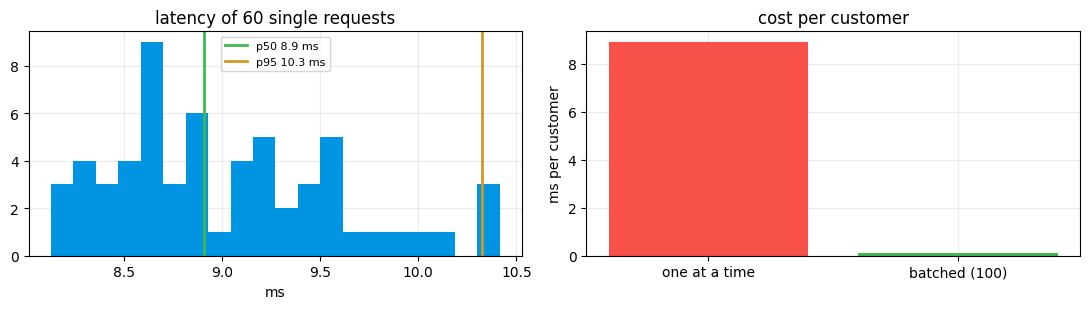

In [19]:
%matplotlib inline
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].hist(single, bins=20, color="#0194e2")
ax[0].axvline(p50, color="#3fb950", lw=2, label=f"p50 {p50:.1f} ms")
ax[0].axvline(p95, color="#d29922", lw=2, label=f"p95 {p95:.1f} ms")
ax[0].set_title("latency of 60 single requests"); ax[0].set_xlabel("ms"); ax[0].legend(fontsize=8)
ax[1].bar(["one at a time", "batched (100)"], [p50, batch_ms/100], color=["#f85149", "#3fb950"])
ax[1].set_ylabel("ms per customer"); ax[1].set_title("cost per customer")
for a in ax: a.grid(alpha=.25); a.set_axisbelow(True)
fig.tight_layout(); plt.show()

## Step 4.2 · `/docs` — the documentation you did not write

FastAPI turns the Pydantic schemas into an OpenAPI specification, and serves an interactive
page from it. Every field, type, bound and example you declared shows up, and callers can try
the endpoint from the browser.

In [20]:
import json, requests
spec = requests.get(f"{URL}/openapi.json").json()
print("paths:", list(spec["paths"]))
print("\nthe /predict request schema, generated from Customer:")
print(json.dumps(spec["components"]["schemas"]["Customer"]["properties"], indent=2)[:500])
print(f"\nInteractive docs:  {URL}/docs")
print(f"Alternative docs:  {URL}/redoc")

paths: ['/health', '/predict', '/predict/batch']

the /predict request schema, generated from Customer:
{
  "tenure_months": {
    "type": "integer",
    "maximum": 600.0,
    "minimum": 0.0,
    "title": "Tenure Months",
    "description": "months since signup"
  },
  "monthly_charge": {
    "type": "number",
    "maximum": 10000.0,
    "minimum": 0.0,
    "title": "Monthly Charge",
    "description": "current monthly bill"
  },
  "support_calls": {
    "type": "integer",
    "maximum": 100.0,
    "minimum": 0.0,
    "title": "Support Calls",
    "description": "calls in the last 90 days"
  },
  

Interactive docs:  http://127.0.0.1:8003/docs
Alternative docs:  http://127.0.0.1:8003/redoc


---
# Part 5 — Advanced   ·   deck slides 31–37

## Step 5.1 · An API key, done simply

Anything reachable needs *some* answer to "who is calling?". A shared key in a header is the
minimum, and `Depends` makes it one line per route.

In [21]:
%%writefile app/secure.py
"""A minimal auth dependency. Real systems use OAuth2/JWT -- the shape is identical."""
import os, secrets
from fastapi import Depends, Header, HTTPException

API_KEY = os.getenv("API_KEY", "dev-key-change-me")


def require_key(x_api_key: str = Header(default="")):
    # compare_digest, not ==, so the comparison time does not leak the key
    if not secrets.compare_digest(x_api_key, API_KEY):
        raise HTTPException(status_code=401, detail="invalid or missing X-API-Key")
    return True

# usage:  @app.post("/predict", dependencies=[Depends(require_key)])

Writing app/secure.py


An API key, added the FastAPI way. `Depends` runs the check before the handler, so the handler
never has to think about authentication.

In [22]:
from fastapi import Depends, FastAPI
from app.secure import require_key
from app.schemas import Customer

demo = FastAPI()

@demo.post("/secure-predict", dependencies=[Depends(require_key)])
def secure_predict(c: Customer):
    return {"ok": True}

with TestClient(demo) as c:
    body = {"tenure_months": 1, "monthly_charge": 10.0, "support_calls": 0, "plan": "basic"}
    print("no key      ->", c.post("/secure-predict", json=body).status_code, "(401 expected)")
    print("wrong key   ->", c.post("/secure-predict", json=body,
                                   headers={"X-API-Key": "nope"}).status_code)
    print("correct key ->", c.post("/secure-predict", json=body,
                                   headers={"X-API-Key": "dev-key-change-me"}).status_code)

2026-09-06 16:55:26,026 INFO HTTP Request: POST http://testserver/secure-predict "HTTP/1.1 401 Unauthorized"
2026-09-06 16:55:26,027 INFO HTTP Request: POST http://testserver/secure-predict "HTTP/1.1 401 Unauthorized"
2026-09-06 16:55:26,028 INFO HTTP Request: POST http://testserver/secure-predict "HTTP/1.1 200 OK"


no key      -> 401 (401 expected)
wrong key   -> 401
correct key -> 200


---
# Where to go next

Everything below is one line away from what you just built. None of it changes the shape.

| You want | Reach for |
|---|---|
| a browser to call you directly | `CORSMiddleware` with an explicit origin list |
| to answer now, finish later | `BackgroundTasks` — the task runs after the response is sent |
| to change the contract safely | `APIRouter(prefix="/v1")`, mount both, retire the old one later |
| real authentication | `fastapi.security` — OAuth2 and JWT, same dependency shape as `require_key` |
| streaming output | `StreamingResponse`, for token-by-token or large files |
| config from the environment | `BaseSettings`, which validates env vars like any other model |

### Running it for real

```bash
uvicorn app.main:app --reload                                  # development only
uvicorn app.main:app --host 0.0.0.0 --port 8000 --workers 4    # production
```

Roughly one worker per CPU core — but each loads **its own copy of the model**, so watch memory
before raising it. Keep `MODEL_PATH` an environment variable, never a hard-coded path: session 4
mounts the model into a container, and session 10 adds metrics to this same app.

### `def` or `async def`?

Use plain `def` for `model.predict()` and anything blocking — FastAPI runs it in a threadpool.
Use `async def` only when the body is genuinely awaiting I/O. An `async def` that blocks stalls
every other request on that worker, which is the one mistake worth remembering.

## Recap

| You wanted to… | Do this |
|---|---|
| describe what you accept | a Pydantic model with `Field(ge=..., le=...)` |
| reject typo'd fields | `ConfigDict(extra="forbid")` |
| restrict a value to a set | `Literal["basic", "plus", "pro"]` |
| load the model once | the `lifespan` context manager |
| promise a response shape | `response_model=Prediction` |
| test the whole API fast | `TestClient(app)` |
| say you are alive | `GET /health`, returning degraded rather than 500 |
| hide internal errors | one `@app.exception_handler(Exception)` |


## Cleanup

Stops the server and removes the sandbox.

In [23]:
import os, shutil, signal
try:
    os.killpg(os.getpgid(SERVER.pid), signal.SIGTERM)
    SERVER.wait(timeout=15)
    print("uvicorn stopped")
except Exception as e:
    print("server already gone:", type(e).__name__)

os.chdir(BASE)
shutil.rmtree(PROJ, ignore_errors=True)
print("sandbox removed")

uvicorn stopped
sandbox removed
